# 任务 2: t-SNE 数据可视化 / Task 2: t-SNE Data Visualization

**Student Dropout and Academic Success Dataset**

本 Notebook 包含以下内容 / This notebook covers:
1. 加载预处理后数据 / Loading preprocessed data
2. 多组 perplexity 参数对比实验 / Multi-perplexity comparison experiment
3. 2D 散点图可视化 / 2D scatter plot visualization
4. 3D 投影可视化 / 3D projection visualization
5. 模式分析与洞察 / Pattern analysis and insights

In [1]:
import sys
import os
import time

# 将项目根目录添加到路径，以便导入 src 模块
# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 导入可视化工具函数 / Import visualization utilities
from src.visualization import (
    compute_tsne,
    plot_tsne_2d,
    plot_tsne_3d,
    plot_perplexity_comparison,
)

# 设置绘图风格 / Set plotting style
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. 加载预处理后数据 / Load Preprocessed Data

In [2]:
# 加载 Task 1 预处理后的数据
# Load preprocessed data from Task 1
features_path = os.path.join(project_root, "data", "features_processed.csv")
targets_path = os.path.join(project_root, "data", "targets_processed.csv")

X = pd.read_csv(features_path)
y = pd.read_csv(targets_path).iloc[:, 0]

print(f"Features shape / 特征维度: {X.shape}")
print(f"Target distribution / 目标分布:")
print(y.value_counts().sort_index().to_string())

Features shape / 特征维度: (4424, 231)
Target distribution / 目标分布:
Target
0    1421
1     794
2    2209


## 2. Perplexity 对比实验 / Perplexity Comparison

t-SNE 的 perplexity 参数控制对局部/全局结构的平衡：
- **低 perplexity (5)**: 关注极局部结构，可能产生过多小聚类
- **中 perplexity (30)**: sklearn 默认值，通常效果良好
- **高 perplexity (50-100)**: 关注更全局的结构，计算更慢

固定 `learning_rate='auto'` 和 `random_state=42`，对比 perplexity=[5, 30, 50, 100] 的效果。

In [3]:
# 定义实验参数 / Define experiment parameters
perplexities = [5, 30, 50, 100]
results_2d = {}

for perp in perplexities:
    print(f"\n--- Running t-SNE with perplexity={perp} ---")
    start = time.time()
    embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
    elapsed = time.time() - start
    print(f"  Time elapsed / 耗时: {elapsed:.1f}s")
    results_2d[perp] = embedding


--- Running t-SNE with perplexity=5 ---


t-SNE done: perplexity=5, n_components=2, shape=(4424, 2)
  Time elapsed / 耗时: 12.9s

--- Running t-SNE with perplexity=30 ---


t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)
  Time elapsed / 耗时: 12.2s

--- Running t-SNE with perplexity=50 ---


t-SNE done: perplexity=50, n_components=2, shape=(4424, 2)
  Time elapsed / 耗时: 14.7s

--- Running t-SNE with perplexity=100 ---


t-SNE done: perplexity=100, n_components=2, shape=(4424, 2)
  Time elapsed / 耗时: 21.8s


## 3. 2D 散点图对比 / 2D Scatter Plot Comparison

Plot saved to E:\Project\2011machine_learning\data\plots\03_tsne_2d_perplexity_comparison.png


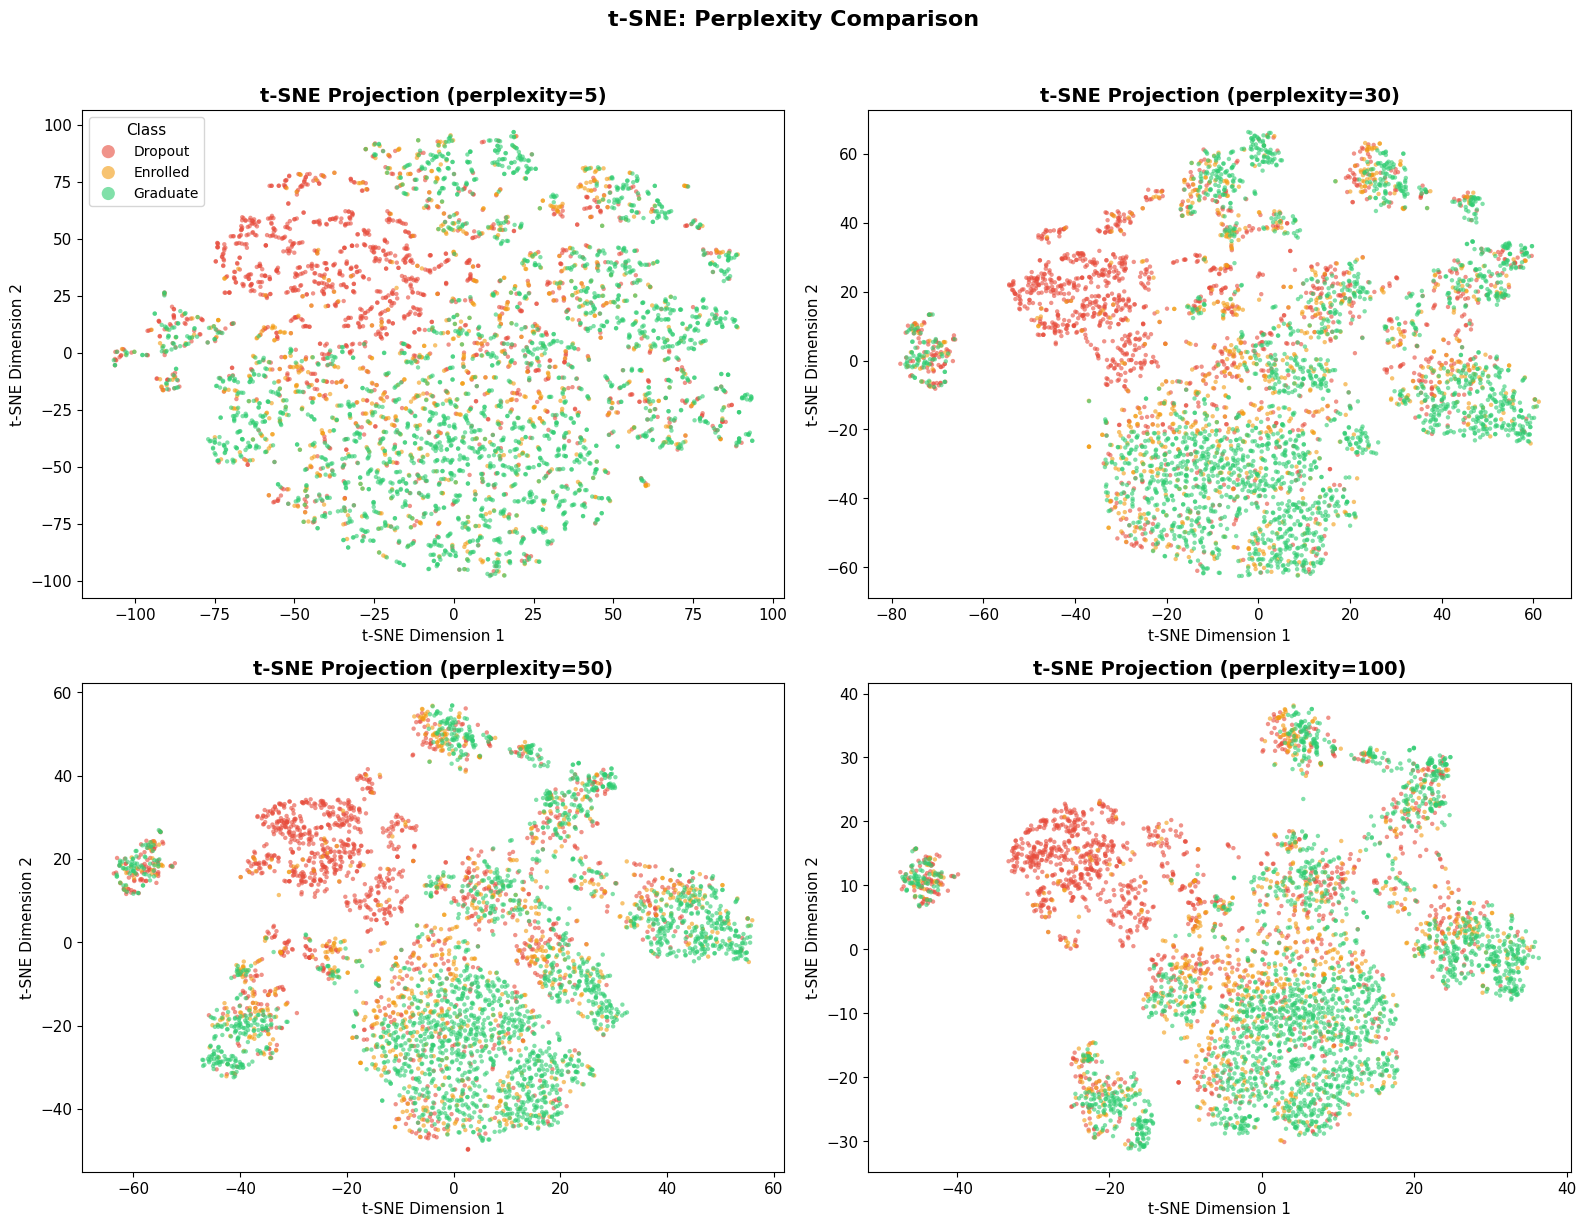

In [4]:
# 绘制 2x2 perplexity 对比图 / Plot 2x2 perplexity comparison
save_path = os.path.join(project_root, "data", "plots", "03_tsne_2d_perplexity_comparison.png")
fig = plot_perplexity_comparison(results_2d, y.values, save_path=save_path)
plt.show()

## 4. 最佳参数 2D 散点图 / Best Perplexity 2D Plot

选取 perplexity=30（默认值）作为最佳参数，单独展示 2D 投影效果。

Plot saved to E:\Project\2011machine_learning\data\plots\04_tsne_2d_best.png


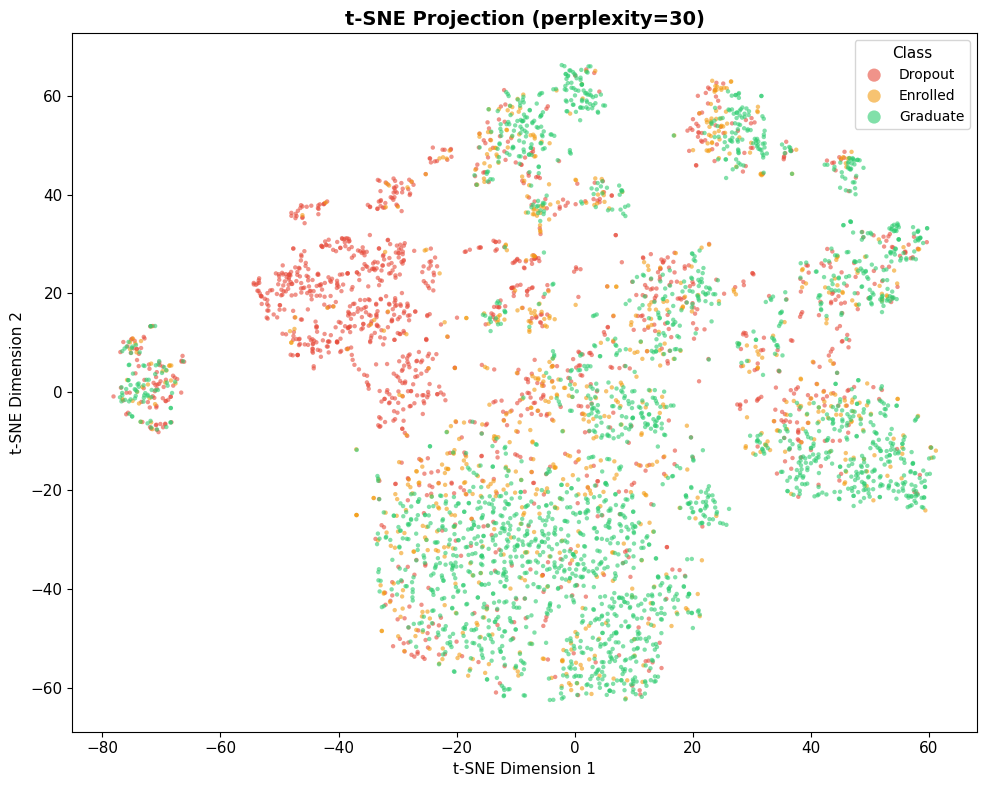

In [5]:
# 使用最佳 perplexity 单独绘制 2D 图 / Plot standalone 2D at best perplexity
best_perp = 30
save_path_2d = os.path.join(project_root, "data", "plots", "04_tsne_2d_best.png")
plot_tsne_2d(results_2d[best_perp], y.values, perplexity=best_perp, save_path=save_path_2d)
plt.show()

## 5. 3D 投影 / 3D Projection

使用最佳 perplexity 参数进行 3D t-SNE 降维。

--- Running 3D t-SNE ---


t-SNE done: perplexity=30, n_components=3, shape=(4424, 3)
  Time elapsed / 耗时: 23.9s


Plot saved to E:\Project\2011machine_learning\data\plots\05_tsne_3d_best.png


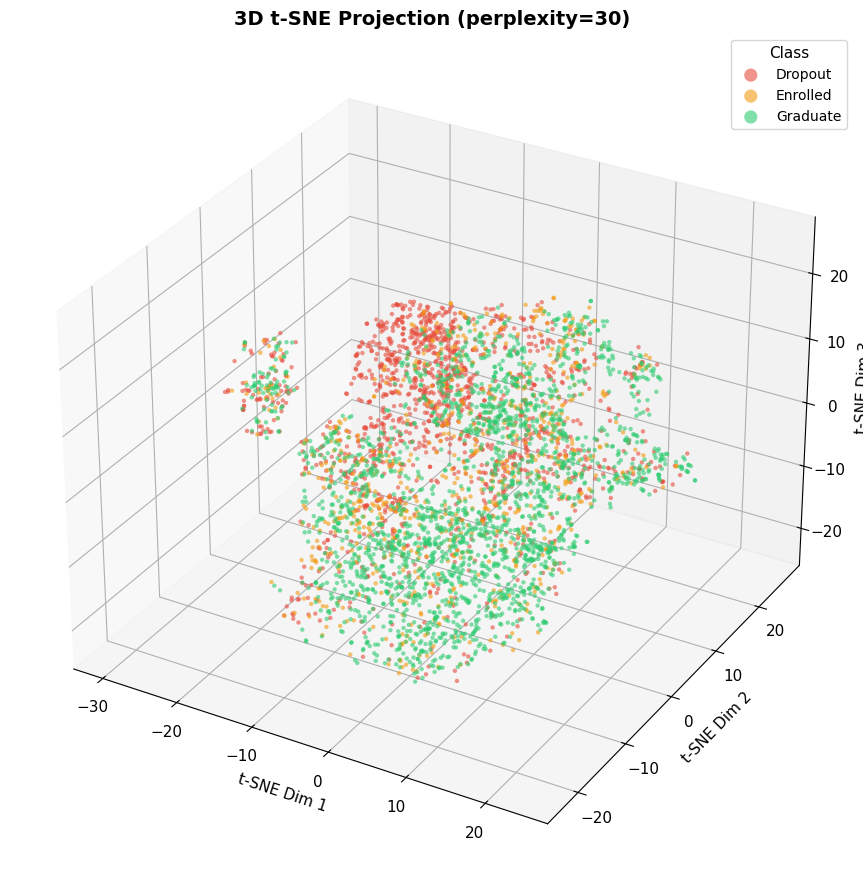

In [6]:
# 计算并绘制 3D t-SNE / Compute and plot 3D t-SNE
print("--- Running 3D t-SNE ---")
start = time.time()
embedding_3d = compute_tsne(X.values, perplexity=best_perp, n_components=3)
print(f"  Time elapsed / 耗时: {time.time() - start:.1f}s")

save_path_3d = os.path.join(project_root, "data", "plots", "05_tsne_3d_best.png")
fig_3d = plot_tsne_3d(embedding_3d, y.values, perplexity=best_perp, save_path=save_path_3d)
plt.show()

## 6. 模式分析与洞察 / Pattern Analysis & Insights

### 主要观察 / Key Observations

1. **类别分离度 / Class Separability**: Graduate（绿色）和 Dropout（红色）在 t-SNE 空间中形成了较为清晰的聚集区域，表明这两个类别在特征空间中具有可区分的模式。Enrolled（橙色）则分布较为分散，与 Dropout 和 Graduate 均存在重叠，这与其作为"过渡状态"的语义一致 — 在读学生可能更接近毕业也可能更接近退学。

2. **Perplexity 的影响 / Effect of Perplexity**:
   - 低 perplexity (5): 形成过多细小碎片聚类，虽然保留了局部细节，但全局结构不清晰，三个类别的整体分布模式难以辨识
   - 默认 perplexity (30): 全局与局部的最佳平衡点，Graduate 和 Dropout 形成了可辨识的聚类区域，是推荐使用的参数
   - 高 perplexity (50, 100): 进一步强调全局结构，聚类边界趋于平滑，但 perplexity=100 时细节丢失较多，且计算时间显著增加（21.8s vs 12.2s）

3. **2D vs 3D**: 3D 投影在第三维度上提供了额外的空间分离度，Graduate 和 Dropout 的重叠有所减少。然而，3D 散点图在静态展示时不如 2D 直观，更适合交互式探索。

### 结论 / Conclusion

t-SNE 能够有效区分 Graduate 和 Dropout 两个类别，在 perplexity=30-50 时效果最佳。Enrolled 类别由于其过渡性质，与两者均存在重叠，这对后续分类任务意味着：Graduate 和 Dropout 的分类边界相对清晰，而 Enrolled 是最具挑战性的类别。建议在后续的聚类分析中关注是否能从 Enrolled 类别中进一步识别出"趋向毕业"和"趋向退学"的子群体。